# Tratamento dos dados - LUAD

Tratamento dos dados do subtipo LUAD para análise de sobrevida.

## Imports

In [ ]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter
from statsmodels.stats.multitest import multipletests

## Settings

In [ ]:
cohort = "LUAD"

project_dir = Path("..").resolve()

raw_dir = project_dir / "data" / "raw" / "luad"
processed_dir = project_dir / "data" / "processed" / "luad"
figures_dir = project_dir / "reports" / "figures" / "luad"

processed_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

files = {
    "surv": raw_dir / "survival_luad.txt",
    "clin": raw_dir / "TCGA-LUAD.clinical.tsv",
    "expr": raw_dir / "HiSeqV2",
}

time_col = "surv__OS.time"
event_col = "surv__OS"

seed = 42

## 1. Dados de sobrevida

In [ ]:
def criar_patient_id(sample):
    if pd.isna(sample):
        return np.nan
    return str(sample)[:12]


def pegar_sample_code(sample):
    if pd.isna(sample):
        return ""
    sample = str(sample)
    partes = sample.split("-")
    if len(partes) >= 4:
        return partes[3][:2]
    achou = re.search(r"-(\d{2})[A-Z]?", sample)
    if achou:
        return achou.group(1)
    return ""


def limpar_nome_gene(gene):
    if pd.isna(gene):
        return gene
    gene = str(gene)
    gene = gene.replace("\u200b", "")
    gene = gene.strip()
    return gene


def mostrar_resumo(df, nome):
    print(f"\n{nome}")
    print("Shape:", df.shape)
    print("Total de nulos:", int(df.isna().sum().sum()))
    df.head()

## 1. Tratamento da base de sobrevida

In [ ]:
luad_surv = (
    pd.read_csv(files["surv"], sep="\t", index_col=0)
    .reset_index()
    .rename(columns={"index": "sample_id"})
)

print("Tamanho:", luad_surv.shape)
print("Colunas:", luad_surv.columns.tolist())

luad_surv.head()

Tamanho: (641, 11)
Colunas: ['sample', '_PATIENT', 'OS', 'OS.time', 'DSS', 'DSS.time', 'DFI', 'DFI.time', 'PFI', 'PFI.time', 'Redaction']


,sample,_PATIENT,OS,OS.time,DSS,DSS.time,DFI,DFI.time,PFI,PFI.time,Redaction
0,TCGA-05-4244-01,TCGA-05-4244,0,0.0,0.0,0.0,NaN,NaN,0,0.0,NaN
1,TCGA-05-4249-01,TCGA-05-4249,0,1523.0,0.0,1523.0,NaN,NaN,0,1523.0,NaN
2,TCGA-05-4250-01,TCGA-05-4250,1,121.0,NaN,121.0,NaN,NaN,0,121.0,NaN
3,TCGA-05-4382-01,TCGA-05-4382,0,607.0,0.0,607.0,1.0,334.0,1,334.0,NaN
4,TCGA-05-4384-01,TCGA-05-4384,0,426.0,0.0,426.0,NaN,NaN,1,183.0,NaN


In [ ]:
#padronização do patient
if "_PATIENT" in luad_surv.columns:
    luad_surv["patient_id"] = luad_surv["_PATIENT"].astype(str)
elif "sample" in luad_surv.columns:
    luad_surv["patient_id"] = luad_surv["sample"].apply(criar_patient_id)
else:
    luad_surv["patient_id"] = luad_surv["sample_id"].apply(criar_patient_id)

luad_surv.head()

,sample,_PATIENT,OS,OS.time,DSS,DSS.time,DFI,DFI.time,PFI,PFI.time,Redaction,patient_id
0,TCGA-05-4244-01,TCGA-05-4244,0,0.0,0.0,0.0,NaN,NaN,0,0.0,NaN,TCGA-05-4244
1,TCGA-05-4249-01,TCGA-05-4249,0,1523.0,0.0,1523.0,NaN,NaN,0,1523.0,NaN,TCGA-05-4249
2,TCGA-05-4250-01,TCGA-05-4250,1,121.0,NaN,121.0,NaN,NaN,0,121.0,NaN,TCGA-05-4250
3,TCGA-05-4382-01,TCGA-05-4382,0,607.0,0.0,607.0,1.0,334.0,1,334.0,NaN,TCGA-05-4382
4,TCGA-05-4384-01,TCGA-05-4384,0,426.0,0.0,426.0,NaN,NaN,1,183.0,NaN,TCGA-05-4384


In [ ]:
# os e os time como númericas
luad_surv["OS"] = pd.to_numeric(luad_surv["OS"], errors="coerce")
luad_surv["OS.time"] = pd.to_numeric(luad_surv["OS.time"], errors="coerce")
# criar colunas de tempo em meses e anos
luad_surv["OS_months"] = luad_surv["OS.time"] / 30.44
luad_surv["OS_years"] = luad_surv["OS.time"] / 365.25

luad_surv[["patient_id", "OS", "OS.time", "OS_months", "OS_years"]].head()

,patient_id,OS,OS.time,OS_months,OS_years
0,TCGA-05-4244,0,0.0,0.000000,0.000000
1,TCGA-05-4249,0,1523.0,50.032852,4.169747
2,TCGA-05-4250,1,121.0,3.975033,0.331280
3,TCGA-05-4382,0,607.0,19.940867,1.661875
4,TCGA-05-4384,0,426.0,13.994744,1.166324


In [ ]:
# identificar qual coluna tem a amostra
if "sample" in luad_surv.columns:
    sample_col_surv = "sample"
else:
    sample_col_surv = "sample_id"

# Pegar o código da amostra - os últimos dois números
luad_surv["sample_code"] = luad_surv[sample_col_surv].apply(pegar_sample_code)

print("Contagem dos códigos de amostra:")
print(luad_surv["sample_code"].value_counts(dropna=False))

Contagem dos códigos de amostra:
sample_code
01    519
11    120
02      2
Name: count, dtype: int64


In [ ]:
# Filtrar apenas com o final 01 - tumor primário 
luad_surv_01 = luad_surv[luad_surv["sample_code"] == "01"].copy()

print("Shape após filtro o filtro do tumor primário", luad_surv_01.shape)

luad_surv_01[[sample_col_surv, "patient_id", "OS", "OS.time"]].head()

Shape após filtro o filtro do tumor primário (519, 15)


,sample,patient_id,OS,OS.time
0,TCGA-05-4244-01,TCGA-05-4244,0,0.0
1,TCGA-05-4249-01,TCGA-05-4249,0,1523.0
2,TCGA-05-4250-01,TCGA-05-4250,1,121.0
3,TCGA-05-4382-01,TCGA-05-4382,0,607.0
4,TCGA-05-4384-01,TCGA-05-4384,0,426.0


In [ ]:
# remoção de duplicatas
antes = len(luad_surv_01)

luad_surv_01 = (
    luad_surv_01
    .sort_values(sample_col_surv)
    .drop_duplicates(subset=["patient_id"], keep="first")
    .copy()
)

depois = len(luad_surv_01)

print("Duplicados removidos:", antes - depois)
print("Pacientes únicos:", luad_surv_01["patient_id"].nunique())

Duplicados removidos: 0
Pacientes únicos: 519


In [ ]:
print("Média de OS=1:", round(luad_surv_01["OS"].mean(skipna=True), 4))

print("OS.time minimo, médio e máximo:",
      luad_surv_01["OS.time"].min(skipna=True),
      luad_surv_01["OS.time"].median(skipna=True),
      luad_surv_01["OS.time"].max(skipna=True))

print("OS faltando:", luad_surv_01["OS"].isna().sum())
print("OS.time faltando:", luad_surv_01["OS.time"].isna().sum())

print("OS inválidos:",
      (~luad_surv_01["OS"].isin([0, 1]) & luad_surv_01["OS"].notna()).sum())

print("OS.time <= 0:",
      (luad_surv_01["OS.time"].fillna(np.inf) <= 0).sum())

Média de OS=1: 0.3622
OS.time minimo, médio e máximo: 0.0 654.5 7248.0
OS faltando: 0
OS.time faltando: 9
OS inválidos: 0
OS.time <= 0: 4


In [ ]:
luad_surv_01["os_missing"] = luad_surv_01["OS"].isna().astype(int)
luad_surv_01["os_time_missing"] = luad_surv_01["OS.time"].isna().astype(int)

luad_surv_01["os_invalid"] = (
    ~luad_surv_01["OS"].isin([0, 1]) & luad_surv_01["OS"].notna()
).astype(int)

luad_surv_01["os_time_<=0"] = (
    luad_surv_01["OS.time"].fillna(np.inf) <= 0
).astype(int)

luad_surv_01["OS.time_clean"] = luad_surv_01["OS.time"].where(
    luad_surv_01["OS.time"] > 0,
    np.nan
)

antes = len(luad_surv_01)

luad_surv_model = luad_surv_01[
    luad_surv_01["OS"].isin([0, 1])
    & luad_surv_01["OS.time_clean"].notna()
].copy()

depois = len(luad_surv_model)

print("Antes:", antes)
print("Depois:", depois)
print("Removidos:", antes - depois)
print("Após o filtro:", round(luad_surv_model["OS"].mean() * 100, 2), "%")

print("OS.time_clean min/med/max:",
      luad_surv_model["OS.time_clean"].min(),
      luad_surv_model["OS.time_clean"].median(),
      luad_surv_model["OS.time_clean"].max())

Antes: 519
Depois: 506
Removidos: 13
Após o filtro: 36.17 %
OS.time_clean min/med/max: 4.0 657.5 7248.0


In [ ]:
luad_surv_final = (
    luad_surv_model[["patient_id", "OS.time_clean", "OS"]]
    .rename(columns={"OS.time_clean": "OS.time"})
    .copy()
)

luad_surv_final = luad_surv_final.set_index("patient_id")

mostrar_resumo(luad_surv_final, "LUAD survival final")


LUAD survival final
Shape: (506, 2)
Total de nulos: 0


In [ ]:
luad_surv_final.reset_index().to_csv(
    processed_dir / "luad_survival_clean.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

print(processed_dir / "luad_survival_clean.csv")

/workspaces/An-lise-de-Sobrevida/data/processed/luad/luad_survival_clean.csv


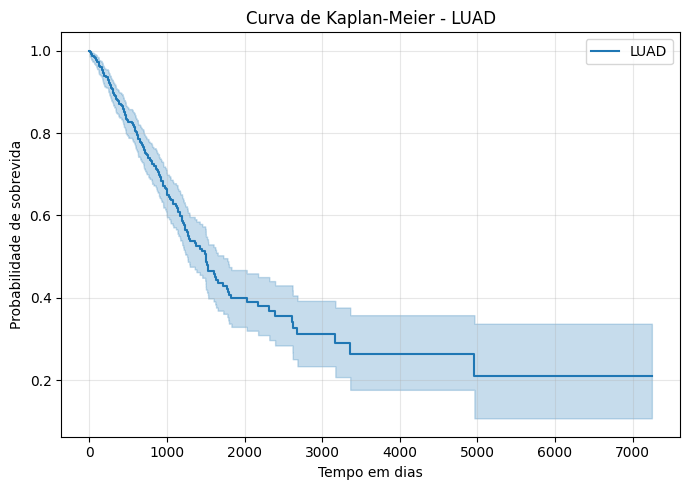

/workspaces/An-lise-de-Sobrevida/reports/figures/luad/luad_kaplan_meier.png


In [ ]:
kmf = KaplanMeierFitter()

kmf.fit(
    durations=luad_surv_final["OS.time"],
    event_observed=luad_surv_final["OS"],
    label="LUAD"
)

fig, ax = plt.subplots(figsize=(7, 5))

kmf.plot_survival_function(ax=ax, ci_show=True)

ax.set_title("Curva de Kaplan-Meier - LUAD")
ax.set_xlabel("Tempo em dias")
ax.set_ylabel("Probabilidade de sobrevida")
ax.grid(alpha=0.3)

fig.tight_layout()

fig.savefig(
    figures_dir / "luad_kaplan_meier.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(figures_dir / "luad_kaplan_meier.png")

In [ ]:
resumo_surv_luad = pd.DataFrame({
    "coorte": ["LUAD"],
    "n_pacientes": [len(luad_surv_final)],
    "n_eventos": [int(luad_surv_final["OS"].sum())],
    "n_censurados": [int((luad_surv_final["OS"] == 0).sum())],
    "eventos=1_%": [round(luad_surv_final["OS"].mean() * 100, 2)],
    "tempo_min_dias": [luad_surv_final["OS.time"].min()],
    "tempo_mediano_dias": [luad_surv_final["OS.time"].median()],
    "tempo_max_dias": [luad_surv_final["OS.time"].max()],
})

resumo_surv_luad

resumo_surv_luad.to_csv(
    processed_dir / "luad_survival_summary.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

## 3. Dados Clínicos

In [ ]:
luad_clin = (
    pd.read_csv(files["clin"], sep="\t", index_col=0)
    .reset_index()
    .rename(columns={"index": "sample_id"})
)

print("Tamanho:", luad_clin.shape)
print("Primeiras colunas:", list(luad_clin.columns[:30]))

luad_clin.head()

Tamanho: (721, 89)
Primeiras colunas: ['sample', 'id', 'disease_type', 'case_id', 'submitter_id', 'primary_site', 'cigarettes_per_day.exposures', 'alcohol_history.exposures', 'years_smoked.exposures', 'pack_years_smoked.exposures', 'race.demographic', 'gender.demographic', 'ethnicity.demographic', 'vital_status.demographic', 'age_at_index.demographic', 'days_to_birth.demographic', 'year_of_birth.demographic', 'year_of_death.demographic', 'primary_site.project', 'project_id.project', 'disease_type.project', 'name.project', 'name.program.project', 'tissue_source_site_id.tissue_source_site', 'code.tissue_source_site', 'name.tissue_source_site', 'project.tissue_source_site', 'bcr_id.tissue_source_site', 'days_to_death.demographic', 'entity_submitter_id.annotations']


,sample,id,disease_type,case_id,submitter_id,primary_site,cigarettes_per_day.exposures,alcohol_history.exposures,years_smoked.exposures,pack_years_smoked.exposures,...,initial_weight.samples,preservation_method.samples,intermediate_dimension.samples,pathology_report_uuid.samples,shortest_dimension.samples,oct_embedded.samples,specimen_type.samples,longest_dimension.samples,is_ffpe.samples,tissue_type.samples
0,TCGA-55-A48X-01A,32d9935a-f5cd-43b3-88bd-09e6e2b9090d,Adenomas and Adenocarcinomas,32d9935a-f5cd-43b3-88bd-09e6e2b9090d,TCGA-55-A48X,Bronchus and lung,1.972603,Not Reported,36.0,36.0,...,30.0,Unknown,NaN,4D06D10F-60F5-4417-BD8E-F2BBCA84BEEB,NaN,False,Solid Tissue,NaN,False,Tumor
1,TCGA-NJ-A55R-01A,7c7d777b-bf00-4c24-97fc-922580d5605f,Adenomas and Adenocarcinomas,7c7d777b-bf00-4c24-97fc-922580d5605f,TCGA-NJ-A55R,Bronchus and lung,0.273973,Not Reported,NaN,5.0,...,200.0,OCT,NaN,726A5F6E-4592-49AA-976F-556CABABDD3D,NaN,True,Solid Tissue,NaN,False,Tumor
2,TCGA-53-A4EZ-01A,7ca711ec-9ac0-4fa7-8a60-32ae84b8789a,Acinar Cell Neoplasms,7ca711ec-9ac0-4fa7-8a60-32ae84b8789a,TCGA-53-A4EZ,Bronchus and lung,2.191781,Not Reported,40.0,40.0,...,120.0,OCT,NaN,E4CB6C1D-9774-47BE-989E-F9CD05D9EED8,NaN,True,Solid Tissue,NaN,False,Tumor
3,TCGA-44-6777-01A,349e6f38-2c67-4a69-a777-b9173a2a27cf,Adenomas and Adenocarcinomas,349e6f38-2c67-4a69-a777-b9173a2a27cf,TCGA-44-6777,Bronchus and lung,3.506849,Not Reported,64.0,64.0,...,NaN,Unknown,1.0,600a1078-21f2-4267-9d3c-03f292fa6a32,0.4,NaN,Solid Tissue,1.8,False,Tumor
4,TCGA-44-6777-11A,349e6f38-2c67-4a69-a777-b9173a2a27cf,Adenomas and Adenocarcinomas,349e6f38-2c67-4a69-a777-b9173a2a27cf,TCGA-44-6777,Bronchus and lung,3.506849,Not Reported,64.0,64.0,...,NaN,Unknown,0.6,NaN,0.4,NaN,Solid Tissue,1.0,False,Normal


## Tratamento dos dados clínicos

In [ ]:
# Criar patient_id
if "submitter_id" in luad_clin.columns:
    luad_clin["patient_id"] = luad_clin["submitter_id"].astype(str)
else:
    luad_clin["patient_id"] = luad_clin["sample_id"].apply(criar_patient_id)

# Criar sample_code
if "sample" in luad_clin.columns:
    sample_col_clin = "sample"
elif "sample_id.samples" in luad_clin.columns:
    sample_col_clin = "sample_id.samples"
else:
    sample_col_clin = "sample_id"

luad_clin["sample_code"] = luad_clin[sample_col_clin].apply(pegar_sample_code)

luad_clin[[sample_col_clin, "patient_id", "sample_code"]].head()

print("Contagem sample_code:")
print(luad_clin["sample_code"].value_counts(dropna=False).head())

Contagem sample_code:
sample_code
01    599
11    120
02      2
Name: count, dtype: int64


In [ ]:
# Filtrar apenas tumor primário
luad_clin_01 = luad_clin[luad_clin["sample_code"] == "01"].copy()

print("Depois do filtro == 01:", luad_clin_01.shape)
print("Pacientes únicos:", luad_clin_01["patient_id"].nunique())

Depois do filtro == 01: (599, 91)
Pacientes únicos: 583


In [ ]:
antes = len(luad_clin_01)

luad_clin_01 = (
    luad_clin_01
    .sort_values(sample_col_clin)
    .drop_duplicates(subset=["patient_id"], keep="first")
    .copy()
)

depois = len(luad_clin_01)

print("Duplicatas removidas:", antes - depois)
print("Shape final:", luad_clin_01.shape)
print("Pacientes únicos:", luad_clin_01["patient_id"].nunique())

Duplicatas removidas: 16
Shape final: (583, 91)
Pacientes únicos: 583


In [ ]:
# Seleção das colunas clínicas que serão analisadas
cols_wanted = [
    "patient_id",
    "submitter_id",
    "case_id",
    "sample_id.samples",
    "age_at_index.demographic",
    "age_at_earliest_diagnosis_in_years.diagnoses.xena_derived",
    "gender.demographic",
    "vital_status.demographic",
    "prior_malignancy.diagnoses",
    "prior_treatment.diagnoses",
    "treatment_type.treatments.diagnoses",
    "treatment_or_therapy.treatments.diagnoses",
    "ajcc_pathologic_stage.diagnoses",
    "ajcc_pathologic_t.diagnoses",
    "ajcc_pathologic_n.diagnoses",
    "ajcc_pathologic_m.diagnoses",
    "primary_diagnosis.diagnoses",
    "morphology.diagnoses",
    "icd_10_code.diagnoses",
    "tissue_or_organ_of_origin.diagnoses",
    "site_of_resection_or_biopsy.diagnoses",
    "pack_years_smoked.exposures",
    "cigarettes_per_day.exposures",
]

missing = [c for c in cols_wanted if c not in luad_clin_01.columns]
present = [c for c in cols_wanted if c in luad_clin_01.columns]

luad_clin_sel = luad_clin_01[present].copy()

print("tamanho:", luad_clin_sel.shape)
print("Colunas ausentes:", missing)

luad_clin_sel.head()

tamanho: (583, 23)
Colunas ausentes: []


,patient_id,submitter_id,case_id,sample_id.samples,age_at_index.demographic,age_at_earliest_diagnosis_in_years.diagnoses.xena_derived,gender.demographic,vital_status.demographic,prior_malignancy.diagnoses,prior_treatment.diagnoses,...,ajcc_pathologic_t.diagnoses,ajcc_pathologic_n.diagnoses,ajcc_pathologic_m.diagnoses,primary_diagnosis.diagnoses,morphology.diagnoses,icd_10_code.diagnoses,tissue_or_organ_of_origin.diagnoses,site_of_resection_or_biopsy.diagnoses,pack_years_smoked.exposures,cigarettes_per_day.exposures
185,TCGA-05-4244,TCGA-05-4244,34040b83-7e8a-4264-a551-b16621843e28,bac0b02d-ac3b-4784-b8bf-180eadd548a3,70.0,70.553425,male,Alive,no,No,...,T2,N2,M1,"Adenocarcinoma, NOS",8140/3,C34.3,"Lower lobe, lung","Lower lobe, lung",38.0,2.082192
698,TCGA-05-4249,TCGA-05-4249,4addf05f-3668-4b3f-a17f-c0227329ca52,80f196fe-1eaf-40cb-ab58-c84795acc5c7,67.0,67.210959,male,Alive,no,No,...,T2,N0,M0,"Adenocarcinoma, NOS",8140/3,C34.3,"Lower lobe, lung","Lower lobe, lung",52.0,2.849315
420,TCGA-05-4250,TCGA-05-4250,f98ecd8a-b878-4f53-b911-20cd8e17281c,8f274178-7a8e-46b6-8d2c-900338bbb946,79.0,79.638356,female,Dead,no,No,...,T3,N1,M0,"Adenocarcinoma, NOS",8140/3,C34.3,"Lower lobe, lung","Lower lobe, lung",47.0,2.575342
529,TCGA-05-4382,TCGA-05-4382,3434b91a-c05f-460f-a078-7b1bb6e7085d,cce6d71f-369e-467f-bd7e-03d20e97b7f3,68.0,68.131507,male,Alive,yes,No,...,T2,N0,M0,Adenocarcinoma with mixed subtypes,8255/3,C34.1,"Upper lobe, lung","Upper lobe, lung",62.0,3.397260
495,TCGA-05-4384,TCGA-05-4384,9a50e7e4-831d-489f-87d2-979e987561cc,e4416303-50b0-4316-bfee-030c7b29fac6,66.0,66.879452,male,Alive,yes,No,...,T2,N2,M0,Adenocarcinoma with mixed subtypes,8255/3,C34.3,"Lower lobe, lung","Lower lobe, lung",20.0,1.095890


In [ ]:
nulos_por_coluna = (
    luad_clin_sel
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

nulos_por_coluna = nulos_por_coluna[nulos_por_coluna > 0]

nulos_por_coluna

cigarettes_per_day.exposures                                 228
pack_years_smoked.exposures                                  228
age_at_earliest_diagnosis_in_years.diagnoses.xena_derived     94
age_at_index.demographic                                      82
ajcc_pathologic_stage.diagnoses                               71
ajcc_pathologic_m.diagnoses                                   67
ajcc_pathologic_n.diagnoses                                   64
ajcc_pathologic_t.diagnoses                                   63
treatment_or_therapy.treatments.diagnoses                     63
prior_treatment.diagnoses                                     63
primary_diagnosis.diagnoses                                   63
gender.demographic                                            63
treatment_type.treatments.diagnoses                           63
vital_status.demographic                                      63
prior_malignancy.diagnoses                                    63
icd_10_code.diagnoses    

In [ ]:
print("Valores de vital_status:")
print(luad_clin_sel["vital_status.demographic"].value_counts(dropna=False))

antes = len(luad_clin_sel)

luad_clin_sel = luad_clin_sel.dropna(subset=["vital_status.demographic"]).copy()

depois = len(luad_clin_sel)

print("Removidos por vital_status ausente:", antes - depois)
print("Linhas restantes:", len(luad_clin_sel))

Valores de vital_status:
vital_status.demographic
Alive    332
Dead     188
NaN       63
Name: count, dtype: int64
Removidos por vital_status ausente: 63
Linhas restantes: 520


In [ ]:
print("Valores de vital_status:")
print(luad_clin_sel["vital_status.demographic"].value_counts(dropna=False))

antes = len(luad_clin_sel)

luad_clin_sel = luad_clin_sel.dropna(subset=["vital_status.demographic"]).copy()

depois = len(luad_clin_sel)

print("Removidos por vital_status ausente:", antes - depois)
print("Linhas restantes:", len(luad_clin_sel))

Valores de vital_status:
vital_status.demographic
Alive    332
Dead     188
Name: count, dtype: int64
Removidos por vital_status ausente: 0
Linhas restantes: 520


In [ ]:
def padronizar_estagio(valor):
    if pd.isna(valor):
        return "Unknown"
    valor = str(valor).upper().strip()
    if "NOT" in valor or "UNKNOWN" in valor or valor == "":
        return "Unknown"
    if "IV" in valor:
        return "IV"
    if "III" in valor:
        return "III"
    if "II" in valor:
        return "II"
    if "I" in valor:
        return "I"
    return "Unknown"


def padronizar_t(valor):
    if pd.isna(valor):
        return "TX"
    valor = str(valor).upper().strip()
    if "T4" in valor:
        return "T4"
    if "T3" in valor:
        return "T3"
    if "T2" in valor:
        return "T2"
    if "T1" in valor:
        return "T1"
    if "T0" in valor:
        return "T0"
    return "TX"


def padronizar_n(valor):
    if pd.isna(valor):
        return "NX"
    valor = str(valor).upper().strip()
    if "N3" in valor:
        return "N3"
    if "N2" in valor:
        return "N2"
    if "N1" in valor:
        return "N1"
    if "N0" in valor:
        return "N0"
    return "NX"


def padronizar_m(valor):
    if pd.isna(valor):
        return "MX"
    valor = str(valor).upper().strip()
    if "M1" in valor:
        return "M1"
    if "M0" in valor:
        return "M0"
    return "MX"


def mapear_sim_nao(valor):
    if pd.isna(valor):
        return np.nan
    valor = str(valor).strip().lower()
    if valor in ["yes", "sim"]:
        return 1
    if valor in ["no", "não", "nao"]:
        return 0
    if valor in ["not reported", "unknown", "not available"]:
        return np.nan
    return np.nan

In [ ]:
# Padronizar estágio e TNM
luad_clin_sel["stage_group"] = luad_clin_sel["ajcc_pathologic_stage.diagnoses"].apply(padronizar_estagio)
luad_clin_sel["t_group"] = luad_clin_sel["ajcc_pathologic_t.diagnoses"].apply(padronizar_t)
luad_clin_sel["n_group"] = luad_clin_sel["ajcc_pathologic_n.diagnoses"].apply(padronizar_n)
luad_clin_sel["m_group"] = luad_clin_sel["ajcc_pathologic_m.diagnoses"].apply(padronizar_m)

print("Estágios após padronização:")
print(luad_clin_sel["stage_group"].value_counts(dropna=False))

print("\nT:")
print(luad_clin_sel["t_group"].value_counts(dropna=False))

print("\nN:")
print(luad_clin_sel["n_group"].value_counts(dropna=False))

print("\nM:")
print(luad_clin_sel["m_group"].value_counts(dropna=False))

Estágios após padronização:
stage_group
I          279
II         123
III         84
IV          26
Unknown      8
Name: count, dtype: int64

T:
t_group
T2    279
T1    172
T3     47
T4     19
TX      3
Name: count, dtype: int64

N:
n_group
N0    335
N1     97
N2     74
NX     12
N3      2
Name: count, dtype: int64

M:
m_group
M0    351
MX    144
M1     25
Name: count, dtype: int64


In [ ]:
# Para idade os nulos foram preenchidos com mediana
idade_cols = [
    "age_at_index.demographic",
    "age_at_earliest_diagnosis_in_years.diagnoses.xena_derived"
]

for col in idade_cols:
    if col in luad_clin_sel.columns:
        luad_clin_sel[col] = pd.to_numeric(luad_clin_sel[col], errors="coerce")
        luad_clin_sel[f"{col}_missing"] = luad_clin_sel[col].isna().astype(int)
        luad_clin_sel[col] = luad_clin_sel[col].fillna(luad_clin_sel[col].median())

# Para tabagismo os nulos foram preenchidos com zero, mas criamos flag dizendo que era ausente
tabagismo_cols = [
    "pack_years_smoked.exposures",
    "cigarettes_per_day.exposures"
]

for col in tabagismo_cols:
    if col in luad_clin_sel.columns:
        luad_clin_sel[col] = pd.to_numeric(luad_clin_sel[col], errors="coerce")
        luad_clin_sel[f"{col}_missing"] = luad_clin_sel[col].isna().astype(int)
        luad_clin_sel[col] = luad_clin_sel[col].fillna(0)

luad_clin_sel.head()

,patient_id,submitter_id,case_id,sample_id.samples,age_at_index.demographic,age_at_earliest_diagnosis_in_years.diagnoses.xena_derived,gender.demographic,vital_status.demographic,prior_malignancy.diagnoses,prior_treatment.diagnoses,...,pack_years_smoked.exposures,cigarettes_per_day.exposures,stage_group,t_group,n_group,m_group,age_at_index.demographic_missing,age_at_earliest_diagnosis_in_years.diagnoses.xena_derived_missing,pack_years_smoked.exposures_missing,cigarettes_per_day.exposures_missing
185,TCGA-05-4244,TCGA-05-4244,34040b83-7e8a-4264-a551-b16621843e28,bac0b02d-ac3b-4784-b8bf-180eadd548a3,70.0,70.553425,male,Alive,no,No,...,38.0,2.082192,IV,T2,N2,M1,0,0,0,0
698,TCGA-05-4249,TCGA-05-4249,4addf05f-3668-4b3f-a17f-c0227329ca52,80f196fe-1eaf-40cb-ab58-c84795acc5c7,67.0,67.210959,male,Alive,no,No,...,52.0,2.849315,I,T2,N0,M0,0,0,0,0
420,TCGA-05-4250,TCGA-05-4250,f98ecd8a-b878-4f53-b911-20cd8e17281c,8f274178-7a8e-46b6-8d2c-900338bbb946,79.0,79.638356,female,Dead,no,No,...,47.0,2.575342,III,T3,N1,M0,0,0,0,0
529,TCGA-05-4382,TCGA-05-4382,3434b91a-c05f-460f-a078-7b1bb6e7085d,cce6d71f-369e-467f-bd7e-03d20e97b7f3,68.0,68.131507,male,Alive,yes,No,...,62.0,3.397260,I,T2,N0,M0,0,0,0,0
495,TCGA-05-4384,TCGA-05-4384,9a50e7e4-831d-489f-87d2-979e987561cc,e4416303-50b0-4316-bfee-030c7b29fac6,66.0,66.879452,male,Alive,yes,No,...,20.0,1.095890,III,T2,N2,M0,0,0,0,0


In [ ]:
# preencher nulos de variáveis categóricas com Unknown
cat_para_unknown = [
    "primary_diagnosis.diagnoses",
    "morphology.diagnoses",
    "icd_10_code.diagnoses",
    "tissue_or_organ_of_origin.diagnoses",
    "site_of_resection_or_biopsy.diagnoses",
    "treatment_type.treatments.diagnoses",
    "treatment_or_therapy.treatments.diagnoses",
]

for col in cat_para_unknown:
    if col in luad_clin_sel.columns:
        luad_clin_sel[col] = luad_clin_sel[col].fillna("Unknown")

nulos = luad_clin_sel.isna().sum()
nulos[nulos > 0].sort_values(ascending=False)

ajcc_pathologic_stage.diagnoses    8
ajcc_pathologic_m.diagnoses        4
ajcc_pathologic_n.diagnoses        1
dtype: int64

In [ ]:
if "age_at_index.demographic" in luad_clin_sel.columns:
    print("Idade min/med/max:",
          luad_clin_sel["age_at_index.demographic"].min(),
          luad_clin_sel["age_at_index.demographic"].median(),
          luad_clin_sel["age_at_index.demographic"].max())

    print("Idade > 100:",
          (luad_clin_sel["age_at_index.demographic"] > 100).sum())

if "pack_years_smoked.exposures" in luad_clin_sel.columns:
    print("\nPack-years min/med/max:",
          luad_clin_sel["pack_years_smoked.exposures"].min(),
          luad_clin_sel["pack_years_smoked.exposures"].median(),
          luad_clin_sel["pack_years_smoked.exposures"].max())

    print("Pack-years > 200:",
          (luad_clin_sel["pack_years_smoked.exposures"] > 200).sum())

Idade min/med/max: 33.0 66.0 88.0
Idade > 100: 0

Pack-years min/med/max: 0.0 24.5 154.0
Pack-years > 200: 0


In [ ]:
df_clin = luad_clin_sel.copy()

df_clin["patient_id"] = df_clin["patient_id"].astype(str)
df_clin = df_clin.set_index("patient_id")

# Sexo: female=0, male=1
df_clin["gender_bin"] = (
    df_clin["gender.demographic"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"female": 0, "male": 1})
)

# Variáveis binárias
if "prior_malignancy.diagnoses" in df_clin.columns:
    df_clin["prior_malignancy_bin"] = df_clin["prior_malignancy.diagnoses"].apply(mapear_sim_nao)

if "prior_treatment.diagnoses" in df_clin.columns:
    df_clin["prior_treatment_bin"] = df_clin["prior_treatment.diagnoses"].apply(mapear_sim_nao)

if "treatment_or_therapy.treatments.diagnoses" in df_clin.columns:
    df_clin["treatment_or_therapy_bin"] = df_clin["treatment_or_therapy.treatments.diagnoses"].apply(mapear_sim_nao)

df_clin["vital_status_bin_audit"] = (
    df_clin["vital_status.demographic"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"alive": 0, "dead": 1, "living": 0, "deceased": 1})
)
df_clin.head()

,submitter_id,case_id,sample_id.samples,age_at_index.demographic,age_at_earliest_diagnosis_in_years.diagnoses.xena_derived,gender.demographic,vital_status.demographic,prior_malignancy.diagnoses,prior_treatment.diagnoses,treatment_type.treatments.diagnoses,...,m_group,age_at_index.demographic_missing,age_at_earliest_diagnosis_in_years.diagnoses.xena_derived_missing,pack_years_smoked.exposures_missing,cigarettes_per_day.exposures_missing,gender_bin,prior_malignancy_bin,prior_treatment_bin,treatment_or_therapy_bin,vital_status_bin_audit
patient_id,,,,,,,,,,,,,,,,,,,,,
TCGA-05-4244,TCGA-05-4244,34040b83-7e8a-4264-a551-b16621843e28,bac0b02d-ac3b-4784-b8bf-180eadd548a3,70.0,70.553425,male,Alive,no,No,"['Pharmaceutical Therapy, NOS', 'Radiation The...",...,M1,0,0,0,0,1,0,0.0,NaN,0
TCGA-05-4249,TCGA-05-4249,4addf05f-3668-4b3f-a17f-c0227329ca52,80f196fe-1eaf-40cb-ab58-c84795acc5c7,67.0,67.210959,male,Alive,no,No,"['Radiation Therapy, NOS', 'Pharmaceutical The...",...,M0,0,0,0,0,1,0,0.0,NaN,0
TCGA-05-4250,TCGA-05-4250,f98ecd8a-b878-4f53-b911-20cd8e17281c,8f274178-7a8e-46b6-8d2c-900338bbb946,79.0,79.638356,female,Dead,no,No,"['Pharmaceutical Therapy, NOS', 'Radiation The...",...,M0,0,0,0,0,0,0,0.0,NaN,1
TCGA-05-4382,TCGA-05-4382,3434b91a-c05f-460f-a078-7b1bb6e7085d,cce6d71f-369e-467f-bd7e-03d20e97b7f3,68.0,68.131507,male,Alive,yes,No,"['Radiation Therapy, NOS', 'Pharmaceutical The...",...,M0,0,0,0,0,1,1,0.0,NaN,0
TCGA-05-4384,TCGA-05-4384,9a50e7e4-831d-489f-87d2-979e987561cc,e4416303-50b0-4316-bfee-030c7b29fac6,66.0,66.879452,male,Alive,yes,No,"['Radiation Therapy, NOS', 'Pharmaceutical The...",...,M0,0,0,0,0,1,1,0.0,NaN,0


In [ ]:
# dummies
cat_cols = [
    "stage_group",
    "t_group",
    "n_group",
    "m_group",
    "primary_diagnosis.diagnoses",
    "morphology.diagnoses",
    "icd_10_code.diagnoses",
    "tissue_or_organ_of_origin.diagnoses",
    "treatment_type.treatments.diagnoses",
]

cat_cols = [c for c in cat_cols if c in df_clin.columns]

luad_clin_final = pd.get_dummies(
    df_clin,
    columns=cat_cols,
    dummy_na=False,
    drop_first=False
)

cols_remover = [
    "submitter_id",
    "case_id",
    "sample_id.samples",
    "gender.demographic",
    "prior_malignancy.diagnoses",
    "prior_treatment.diagnoses",
    "treatment_or_therapy.treatments.diagnoses",
    "ajcc_pathologic_stage.diagnoses",
    "ajcc_pathologic_t.diagnoses",
    "ajcc_pathologic_n.diagnoses",
    "ajcc_pathologic_m.diagnoses",
    "site_of_resection_or_biopsy.diagnoses",
    "vital_status.demographic",
    "vital_status_bin_audit",
]

luad_clin_final = luad_clin_final.drop(columns=cols_remover, errors="ignore")

for col in luad_clin_final.columns:
    luad_clin_final[col] = pd.to_numeric(luad_clin_final[col], errors="coerce")

mostrar_resumo(luad_clin_final, "LUAD clinical final")


LUAD clinical final
Shape: (520, 69)
Total de nulos: 521


In [ ]:
cols_totalmente_vazias = [
    col for col in luad_clin_final.columns
    if luad_clin_final[col].isna().all()
]

print("Colunas totalmente vazias removidas:")
print(cols_totalmente_vazias)

luad_clin_final = luad_clin_final.drop(columns=cols_totalmente_vazias)

for col in luad_clin_final.columns:
    if luad_clin_final[col].isna().sum() > 0:
        mediana = luad_clin_final[col].median()

        if pd.isna(mediana):
            luad_clin_final[col] = luad_clin_final[col].fillna(0)
        else:
            luad_clin_final[col] = luad_clin_final[col].fillna(mediana)

print("Total de nulos no clínico final:", int(luad_clin_final.isna().sum().sum()))
print("Shape:", luad_clin_final.shape)

Colunas totalmente vazias removidas:
['treatment_or_therapy_bin']
Total de nulos no clínico final: 0
Shape: (520, 68)


In [ ]:
luad_clin_final.reset_index().to_csv(
    processed_dir / "luad_clinical_clean.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

print(processed_dir / "luad_clinical_clean.csv")

/workspaces/An-lise-de-Sobrevida/data/processed/luad/luad_clinical_clean.csv


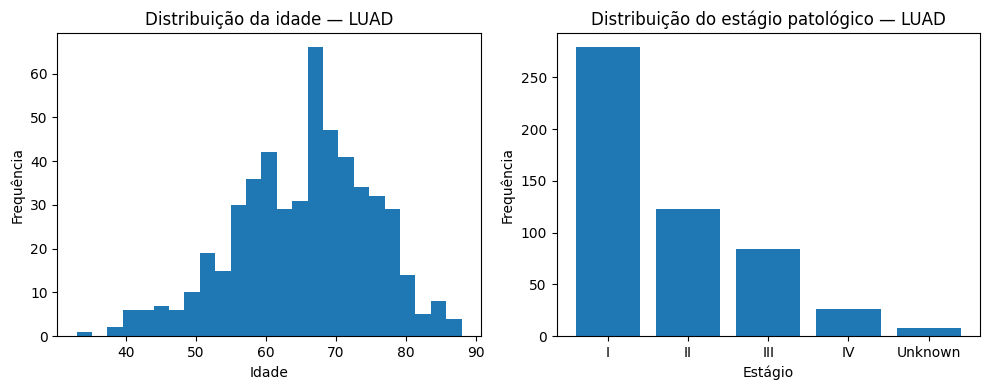

/workspaces/An-lise-de-Sobrevida/reports/figures/luad/luad_clinical_profile.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Idade
idade_col = "age_at_index.demographic"

if idade_col in luad_clin_sel.columns:
    axes[0].hist(luad_clin_sel[idade_col].dropna(), bins=25)
    axes[0].set_title("Distribuição da idade — LUAD")
    axes[0].set_xlabel("Idade")
    axes[0].set_ylabel("Frequência")

# Estágio
ordem_estagios = ["I", "II", "III", "IV", "Unknown"]
stage_counts = luad_clin_sel["stage_group"].value_counts().reindex(ordem_estagios)

axes[1].bar(stage_counts.index.astype(str), stage_counts.values)
axes[1].set_title("Distribuição do estágio patológico — LUAD")
axes[1].set_xlabel("Estágio")
axes[1].set_ylabel("Frequência")

fig.tight_layout()

fig.savefig(
    figures_dir / "luad_clinical_profile.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(figures_dir / "luad_clinical_profile.png")

## 3. Dados de expressão gênica

In [ ]:
luad_expr_raw = pd.read_csv(files["expr"], sep="\t", index_col=0)

print("Shape genes x amostras:", luad_expr_raw.shape)

In [ ]:
luad_expr_t = (
    luad_expr_raw
    .T
    .reset_index()
    .rename(columns={"index": "sample"})
)

luad_expr_t["sample_code"] = luad_expr_t["sample"].apply(pegar_sample_code)
luad_expr_t["patient_id"] = luad_expr_t["sample"].apply(criar_patient_id)

print(luad_expr_t["sample_code"].value_counts(dropna=False).head())

luad_expr_t[["sample", "sample_code", "patient_id"]].head()

In [ ]:
# Manter apenas amostras tumorais primárias
antes = len(luad_expr_t)

luad_expr_t = luad_expr_t[luad_expr_t["sample_code"] == "01"].copy()

depois_filtro = len(luad_expr_t)

# Remover duplicatas por paciente
luad_expr_t = (
    luad_expr_t
    .sort_values("sample")
    .drop_duplicates(subset=["patient_id"], keep="first")
    .copy()
)

depois_dedup = len(luad_expr_t)

print("Antes:", antes)
print("Após filtro tumor primário:", depois_filtro)
print("Após deduplicação:", depois_dedup)
print("Duplicatas removidas:", depois_filtro - depois_dedup)

Antes: 576
Após filtro tumor primário: 515
Após deduplicação: 515
Duplicatas removidas: 0


In [ ]:
luad_expr_final = luad_expr_t.copy()

luad_expr_final = luad_expr_final.set_index("patient_id")

luad_expr_final = luad_expr_final.drop(
    columns=["sample", "sample_code"],
    errors="ignore"
)

luad_expr_final = luad_expr_final.apply(pd.to_numeric, errors="coerce")

mostrar_resumo(luad_expr_final, "LUAD expression final")


LUAD expression final
Shape: (515, 20530)
Total de nulos: 0


In [ ]:
luad_expr_final.reset_index().to_csv(
    processed_dir / "luad_expression_clean.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

print(processed_dir / "luad_expression_clean.csv")

/workspaces/An-lise-de-Sobrevida/data/processed/luad/luad_expression_clean.csv


## 4. Joinar as bases

In [ ]:
surv_ids = set(luad_surv_final.index.astype(str))
clin_ids = set(luad_clin_final.index.astype(str))
expr_ids = set(luad_expr_final.index.astype(str))

resumo_overlap = pd.DataFrame({
    "base": [
        "survival",
        "clinical",
        "expression",
        "survival ∩ clinical",
        "survival ∩ expression",
        "clinical ∩ expression",
        "survival ∩ clinical ∩ expression"
    ],
    "n_pacientes": [
        len(surv_ids),
        len(clin_ids),
        len(expr_ids),
        len(surv_ids & clin_ids),
        len(surv_ids & expr_ids),
        len(clin_ids & expr_ids),
        len(surv_ids & clin_ids & expr_ids)
    ]
})

resumo_overlap

resumo_overlap.to_csv(
    processed_dir / "luad_overlap_summary.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

In [ ]:
surv = luad_surv_final.copy()
clin = luad_clin_final.copy()
expr = luad_expr_final.copy()

surv.index = surv.index.astype(str)
clin.index = clin.index.astype(str)
expr.index = expr.index.astype(str)

surv = surv[~surv.index.duplicated(keep="first")]
clin = clin[~clin.index.duplicated(keep="first")]
expr = expr[~expr.index.duplicated(keep="first")]

# Join
df_luad_final = pd.concat(
    [
        surv.add_prefix("surv__"),
        clin.add_prefix("clin__"),
        expr
    ],
    axis=1,
    join="inner"
)

mostrar_resumo(df_luad_final, "Base integrada LUAD")


Base integrada LUAD
Shape: (502, 20600)
Total de nulos: 0


## 5. Genes selecionados da literatura

In [ ]:
# Genes clássicos de LUAD
genes_luad_classicos = [
    "TP53", "KRAS", "EGFR", "BRAF", "PIK3CA", "MET", "RIT1",
    "STK11", "KEAP1", "NF1", "RB1", "CDKN2A", "SETD2",
    "ARID1A", "SMARCA4", "RBM10", "U2AF1"
]

# Assinatura imune
genes_luad_imune_9 = [
    "BTK", "CCR6", "S100A10", "SEMA3C", "GPI",
    "SCG2", "TNFRSF11A", "CCL20", "DKK1"
]

# Assinatura imune/metástase linfonodal 
genes_luad_imune_8 = [
    "IKBKB", "LTBR", "MIF", "PPARD", "PPIA",
    "PSME3", "S100A6", "SEMA4B"
]

# Assinatura prognóstica/quimioterapia
genes_luad_quimio = [
    "BTK", "FGFR2", "PIM2", "CHEK1", "CDK1"
]

# Assinatura glicolítica
genes_luad_glicolise = [
    "AGRN", "AKR1A1", "DDIT4", "HMMR"
]

genes_literatura = (
    genes_luad_classicos
    + genes_luad_imune_9
    + genes_luad_imune_8
    + genes_luad_quimio
    + genes_luad_glicolise
)

genes_literatura = [limpar_nome_gene(g) for g in genes_literatura]
genes_literatura = list(dict.fromkeys(genes_literatura))

print("Total genes literatura:", len(genes_literatura))
print(genes_literatura)

Total genes literatura: 42
['TP53', 'KRAS', 'EGFR', 'BRAF', 'PIK3CA', 'MET', 'RIT1', 'STK11', 'KEAP1', 'NF1', 'RB1', 'CDKN2A', 'SETD2', 'ARID1A', 'SMARCA4', 'RBM10', 'U2AF1', 'BTK', 'CCR6', 'S100A10', 'SEMA3C', 'GPI', 'SCG2', 'TNFRSF11A', 'CCL20', 'DKK1', 'IKBKB', 'LTBR', 'MIF', 'PPARD', 'PPIA', 'PSME3', 'S100A6', 'SEMA4B', 'FGFR2', 'PIM2', 'CHEK1', 'CDK1', 'AGRN', 'AKR1A1', 'DDIT4', 'HMMR']


In [ ]:
genes_presentes = [g for g in genes_literatura if g in df_luad_final.columns]
genes_ausentes = [g for g in genes_literatura if g not in df_luad_final.columns]

print("Genes presentes:", len(genes_presentes))
print(genes_presentes)

print("\nGenes ausentes:", len(genes_ausentes))
print(genes_ausentes)

tabela_genes_disponibilidade = pd.DataFrame({
    "gene": genes_literatura,
    "presente_na_base": [g in genes_presentes for g in genes_literatura]
})

tabela_genes_disponibilidade

tabela_genes_disponibilidade.to_csv(
    processed_dir / "luad_gene_availability.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

Genes presentes: 42
['TP53', 'KRAS', 'EGFR', 'BRAF', 'PIK3CA', 'MET', 'RIT1', 'STK11', 'KEAP1', 'NF1', 'RB1', 'CDKN2A', 'SETD2', 'ARID1A', 'SMARCA4', 'RBM10', 'U2AF1', 'BTK', 'CCR6', 'S100A10', 'SEMA3C', 'GPI', 'SCG2', 'TNFRSF11A', 'CCL20', 'DKK1', 'IKBKB', 'LTBR', 'MIF', 'PPARD', 'PPIA', 'PSME3', 'S100A6', 'SEMA4B', 'FGFR2', 'PIM2', 'CHEK1', 'CDK1', 'AGRN', 'AKR1A1', 'DDIT4', 'HMMR']

Genes ausentes: 0
[]


## 6. Análise de Cox univariada por gene

In [ ]:
def rodar_cox_univariado(df, genes, time_col, event_col):
    rows = []

    for gene in genes:
        tmp = df[[time_col, event_col, gene]].copy()

        tmp[time_col] = pd.to_numeric(tmp[time_col], errors="coerce")
        tmp[event_col] = pd.to_numeric(tmp[event_col], errors="coerce")
        tmp[gene] = pd.to_numeric(tmp[gene], errors="coerce")

        tmp = tmp.dropna()

        status = "ok"

        if tmp.shape[0] < 20:
            status = "n_insuficiente"
        elif tmp[gene].nunique() < 2:
            status = "sem_variacao_gene"
        elif tmp[event_col].nunique() < 2:
            status = "sem_variacao_evento"
        elif tmp[gene].std() == 0:
            status = "desvio_zero"

        if status != "ok":
            rows.append({
                "gene": gene,
                "n": len(tmp),
                "coef": np.nan,
                "HR": np.nan,
                "se": np.nan,
                "z": np.nan,
                "p": np.nan,
                "ci95_inf": np.nan,
                "ci95_sup": np.nan,
                "status": status
            })
            continue

        tmp[gene] = (tmp[gene] - tmp[gene].mean()) / tmp[gene].std()

        try:
            cph = CoxPHFitter()
            cph.fit(
                tmp,
                duration_col=time_col,
                event_col=event_col
            )

            s = cph.summary.loc[gene]

            rows.append({
                "gene": gene,
                "n": len(tmp),
                "coef": s["coef"],
                "HR": s["exp(coef)"],
                "se": s["se(coef)"],
                "z": s["z"],
                "p": s["p"],
                "ci95_inf": s["exp(coef) lower 95%"],
                "ci95_sup": s["exp(coef) upper 95%"],
                "status": "ok"
            })

        except Exception as e:
            rows.append({
                "gene": gene,
                "n": len(tmp),
                "coef": np.nan,
                "HR": np.nan,
                "se": np.nan,
                "z": np.nan,
                "p": np.nan,
                "ci95_inf": np.nan,
                "ci95_sup": np.nan,
                "status": f"erro: {str(e)}"
            })

    resultado = pd.DataFrame(rows)

    resultado["q_value"] = np.nan
    mask = resultado["p"].notna()

    if mask.sum() > 0:
        resultado.loc[mask, "q_value"] = multipletests(
            resultado.loc[mask, "p"],
            method="fdr_bh"
        )[1]

    resultado["efeito"] = np.where(
        resultado["HR"] > 1,
        "alto_risco",
        np.where(resultado["HR"] < 1, "protetor", "neutro")
    )

    resultado = resultado.sort_values("p", na_position="last").reset_index(drop=True)

    return resultado

In [ ]:
time_col = "surv__OS.time"
event_col = "surv__OS"

res_cox_luad = rodar_cox_univariado(
    df=df_luad_final,
    genes=genes_presentes,
    time_col=time_col,
    event_col=event_col
)

res_cox_luad

,gene,n,coef,HR,se,z,p,ci95_inf,ci95_sup,status,q_value,efeito
0,DKK1,502,0.392389,1.480513,0.072972,5.377248,7.563304e-08,1.283212,1.708150,ok,0.000003,alto_risco
1,HMMR,502,0.328157,1.388407,0.077032,4.259990,2.044357e-05,1.193842,1.614681,ok,0.000429,alto_risco
2,CHEK1,502,0.307728,1.360330,0.073986,4.159290,3.192390e-05,1.176705,1.572610,ok,0.000447,alto_risco
3,CCR6,502,-0.275870,0.758911,0.073844,-3.735842,1.870883e-04,0.656651,0.877096,ok,0.001703,protetor
4,CDK1,502,0.273398,1.314423,0.073582,3.715573,2.027435e-04,1.137896,1.518336,ok,0.001703,alto_risco
5,GPI,502,0.237987,1.268693,0.069460,3.426258,6.119597e-04,1.107216,1.453720,ok,0.004284,alto_risco
6,BTK,502,-0.206729,0.813240,0.065127,-3.174223,1.502382e-03,0.715785,0.923965,ok,0.009014,protetor
7,SEMA3C,502,0.231041,1.259912,0.075406,3.063983,2.184115e-03,1.086813,1.460580,ok,0.011467,alto_risco
8,SEMA4B,502,0.217427,1.242875,0.072110,3.015217,2.567956e-03,1.079064,1.431553,ok,0.011984,alto_risco
9,AKR1A1,502,-0.221878,0.801013,0.074833,-2.964968,3.027148e-03,0.691737,0.927551,ok,0.012714,protetor


In [ ]:
top_p = res_cox_luad[
    (res_cox_luad["status"] == "ok")
    & (res_cox_luad["p"] < 0.05)
].copy()

print("Genes com p < 0.05:", len(top_p))


top_p[["gene", "HR", "ci95_inf", "ci95_sup", "p", "q_value", "efeito", "n"]]

IndentationError: unexpected indent (3681828014.py, line 9)

In [ ]:
genes_top_p = top_p["gene"].tolist()

print("genes_top_p =")
print(genes_top_p)

genes_top_p =
['DKK1', 'HMMR', 'CHEK1', 'CCR6', 'CDK1', 'GPI', 'BTK', 'SEMA3C', 'SEMA4B', 'AKR1A1', 'DDIT4', 'PPIA', 'KRAS', 'S100A10', 'PIM2', 'PSME3', 'CCL20', 'IKBKB', 'MIF', 'FGFR2', 'LTBR', 'MET', 'AGRN']


In [ ]:
res_cox_luad.to_csv(
    processed_dir / "luad_cox_univariate_genes.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

print( processed_dir / "luad_cox_univariate_genes.csv")

Arquivo salvo: /workspaces/An-lise-de-Sobrevida/data/processed/luad/luad_cox_univariate_genes.csv


## 7. Base final para modelagem

In [ ]:
genes_escolhidos = genes_top_p.copy()

surv_cols = [c for c in df_luad_final.columns if c.startswith("surv__")]


clin_cols = [c for c in df_luad_final.columns if c.startswith("clin__")]

clin_cols = [
    c for c in clin_cols
    if "vital_status" not in c.lower()
]

genes_presentes_modelo = [g for g in genes_escolhidos if g in df_luad_final.columns]
genes_ausentes_modelo = [g for g in genes_escolhidos if g not in df_luad_final.columns]

print("Colunas survival:", len(surv_cols))
print("Colunas clínicas:", len(clin_cols))
print("Genes presentes:", genes_presentes_modelo)
print("Genes ausentes:", genes_ausentes_modelo)

cols_finais = surv_cols + clin_cols + genes_presentes_modelo
cols_finais = list(dict.fromkeys(cols_finais))

df_luad_modelo = df_luad_final[cols_finais].copy()

print("Shape final:", df_luad_modelo.shape)

df_luad_modelo.head()

Colunas survival: 2
Colunas clínicas: 68
Genes presentes: ['DKK1', 'HMMR', 'CHEK1', 'CCR6', 'CDK1', 'GPI', 'BTK', 'SEMA3C', 'SEMA4B', 'AKR1A1', 'DDIT4', 'PPIA', 'KRAS', 'S100A10', 'PIM2', 'PSME3', 'CCL20', 'IKBKB', 'MIF', 'FGFR2', 'LTBR', 'MET', 'AGRN']
Genes ausentes: []
Shape final: (502, 93)


,surv__OS.time,surv__OS,clin__age_at_index.demographic,clin__age_at_earliest_diagnosis_in_years.diagnoses.xena_derived,clin__pack_years_smoked.exposures,clin__cigarettes_per_day.exposures,clin__age_at_index.demographic_missing,clin__age_at_earliest_diagnosis_in_years.diagnoses.xena_derived_missing,clin__pack_years_smoked.exposures_missing,clin__cigarettes_per_day.exposures_missing,...,S100A10,PIM2,PSME3,CCL20,IKBKB,MIF,FGFR2,LTBR,MET,AGRN
patient_id,,,,,,,,,,,,,,,,,,,,,
TCGA-05-4249,1523.0,0,67.0,67.210959,52.0,2.849315,0,0,0,0,...,12.2821,10.3286,11.6354,6.5895,12.2902,11.5286,9.1224,10.0792,13.1655,12.8819
TCGA-05-4250,121.0,1,79.0,79.638356,47.0,2.575342,0,0,0,0,...,14.6910,9.3912,12.0324,6.7385,10.1049,12.0569,6.6602,10.6575,13.0816,12.4818
TCGA-05-4382,607.0,0,68.0,68.131507,62.0,3.397260,0,0,0,0,...,15.0031,11.6397,11.6540,10.9371,10.0478,12.7837,9.5406,11.9222,9.9056,14.2954
TCGA-05-4384,426.0,0,66.0,66.879452,20.0,1.095890,0,0,0,0,...,13.3755,8.6719,11.2958,6.8330,10.7145,11.6035,8.4121,11.2125,11.8909,13.4724
TCGA-05-4389,1369.0,0,70.0,70.301370,43.0,2.356164,0,0,0,0,...,14.0021,9.7883,11.9159,8.7170,10.9728,13.1209,7.4608,11.6193,9.9740,11.9684


In [ ]:
nulos_modelo = (
    df_luad_modelo
    .isna()
    .sum()
    .sort_values(ascending=False)
)

nulos_modelo = nulos_modelo[nulos_modelo > 0]

print("Colunas com nulos na base final:")
nulos_modelo

Colunas com nulos na base final:


Series([], dtype: int64)

In [ ]:
for col in df_luad_modelo.columns:
    if col in surv_cols:
        continue

    if df_luad_modelo[col].isna().sum() > 0:
        mediana = df_luad_modelo[col].median()
        df_luad_modelo[col] = df_luad_modelo[col].fillna(mediana)

print("Total de nulos após tratamento:", int(df_luad_modelo.isna().sum().sum()))

Total de nulos após tratamento: 0


In [ ]:
resumo_modelo_luad = pd.DataFrame({
    "coorte": ["LUAD"],
    "n_pacientes": [df_luad_modelo.shape[0]],
    "n_colunas_total": [df_luad_modelo.shape[1]],
    "n_colunas_sobrevida": [len(surv_cols)],
    "n_colunas_clinicas": [len(clin_cols)],
    "n_genes": [len(genes_presentes_modelo)],
    "taxa_eventos_%": [round(df_luad_modelo["surv__OS"].mean() * 100, 2)]
})

resumo_modelo_luad

resumo_modelo_luad.to_csv(
    processed_dir / "luad_modeling_dataset_summary.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

,coorte,n_pacientes,n_colunas_total,n_colunas_sobrevida,n_colunas_clinicas,n_genes,taxa_eventos_%
0,LUAD,502,93,2,68,23,36.25


In [ ]:
df_luad_modelo.reset_index(names="patient_id").to_csv(
    processed_dir / "luad_modeling_dataset.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

print(processed_dir / "luad_modeling_dataset.csv")

/workspaces/An-lise-de-Sobrevida/data/processed/luad/luad_modeling_dataset.csv


In [ ]:
print("FINAL - LUAD")

print("Sobrevida:", luad_surv_final.shape)
print("Clínico:", luad_clin_final.shape)
print("Expressão:", luad_expr_final.shape)
print("Join:", df_luad_final.shape)
print("Modelo:", df_luad_modelo.shape)

print("\nArquivos gerados:")
for arquivo in sorted(processed_dir.glob("*.csv")):
    print("-", arquivo.name)

print("\nFiguras geradas:")
for figura in sorted(figures_dir.glob("*.png")):
    print("-", figura.name)

FINAL - LUAD
Sobrevida: (506, 2)
Clínico: (520, 68)
Expressão: (515, 20530)
Join: (502, 20600)
Modelo: (502, 93)

Arquivos gerados:
- luad_clinical_clean.csv
- luad_clinical_missing_report.csv
- luad_cox_univariate_genes.csv
- luad_expression_clean.csv
- luad_gene_availability.csv
- luad_modeling_dataset.csv
- luad_modeling_dataset_summary.csv
- luad_overlap_summary.csv
- luad_survival_clean.csv
- luad_survival_summary.csv

Figuras geradas:
- luad_clinical_profile.png
- luad_kaplan_meier.png
